In [ ]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = Path('/content/drive/MyDrive/AI-ML-Health-Project-20251113T203434Z-1-001/AI-ML-Health-Project/data') # CHANGE AS NEEDED
JH_SEG_DIR = BASE_DIR / 'JH_seg_labels'
METADATA_PATH = BASE_DIR / 'IARCImageBankVIA' / 'Cases Meta data JH.xlsx'
IARC_DIR = BASE_DIR / 'IARCImageBankVIA'  # IARC images are in Case folders

VIA_MAPPING = {
    'Negative': 0,
    'Suspicious of cancer': 1,
    'Positive': 2,
    'Suspicious': 1
}

def load_metadata(metadata_path):
    df = pd.read_excel(metadata_path)
    df['VIA'] = df['VIA'].astype(str).str.strip()
    df['CaseNumber'] = df['CaseNumber'].astype(str).str.strip()
    df['CaseID'] = df['CaseID'].astype(str).str.strip()
    df['Label'] = df['VIA'].map(VIA_MAPPING)
    return df

metadata_df = load_metadata(METADATA_PATH)

def load_jh_data(datapaths, metadata_df): # datapaths is a list of two paths, the first is the JH data and the second is the IARC data
    image_paths = []
    mask_paths = []
    classification_labels = []
    case_ids = []
    folder_names = []

    # Create mapping: CaseID -> Label (focus on CaseID, not CaseNumber)
    # For JH data, we look for CaseIDs that start with "JH"
    caseid_to_label = {}
    jh_caseid_to_label = {}  # Specifically for CaseIDs starting with "JH"

    for _, row in metadata_df.iterrows():
        case_id = str(row['CaseID']).strip()
        label = row['Label']

        if pd.notna(label) and case_id and case_id != 'nan': # debugging
            caseid_to_label[case_id] = label
            # If CaseID starts with "JH", add to JH-specific mapping
            if case_id.upper().startswith('JH'):
                jh_caseid_to_label[case_id.upper()] = label

    # Parse datapaths - handle both Path objects and strings
    jh_path = None
    iarc_path = None

    for path in datapaths:
        path_str = str(path)  # Convert Path to string for comparison
        if 'JH_seg_labels' in path_str:
            jh_path = Path(path)
        elif 'IARCImageBankVIA' in path_str:
            iarc_path = Path(path)

    # Verify paths were found
    if jh_path is None or iarc_path is None:
        raise ValueError(f"Could not find required paths. JH: {jh_path}, IARC: {iarc_path}")

    # Get all subdirectories in the JH and IARC paths
    jh_folders = [f for f in jh_path.iterdir() if f.is_dir()]
    iarc_folders = [f for f in iarc_path.iterdir() if f.is_dir()]

    for folder in jh_folders: # for each case folder in the JH data
        folder_name = folder.name  # e.g., "JHAA1", "JHAB1"

        # Strip trailing digits to get the CaseID: "JHAA1" → "JHAA"
        import re
        case_id = re.sub(r'\d+$', '', folder_name)  # Remove trailing digits

        if case_id in caseid_to_label: # if the case id is in the caseid_to_label mapping
            label = caseid_to_label[case_id] # get the label
            image_path = folder / 'img.png' # get the image path
            label_path = folder / 'label.png' # get the label path

            if image_path.exists() and label_path.exists(): # if the image and label paths exist
                image_paths.append(image_path) # add the image path to the image paths list
                mask_paths.append(label_path) # add the label path to the mask paths list
                classification_labels.append(label) # add the label to the classification labels list
                case_ids.append(case_id) # add the case id to the case ids list
                folder_names.append(folder_name) # add the folder name to the folder names list

    for folder in iarc_folders: # for each case folder in the IARC data
        # IARC folders are named "Case 001", "Case 002", etc.
        # Images inside are named like "AFC0.jpg", "AFC1.jpg" where AFC is the CaseID

        # Get all jpg files in the folder
        jpg_files = list(folder.glob('*.jpg'))

        if jpg_files:
            # Extract case_id from first jpg filename (e.g., "AFC0.jpg" → "AFC")
            first_jpg = jpg_files[1].stem  # "AFC0"
            case_id = ''.join([c for c in first_jpg if c.isalpha()])  # Extract letters: "AFC"

            if case_id in caseid_to_label: # if the case id is in the caseid_to_label mapping
                label = caseid_to_label[case_id] # get the label

                # Use the first image (typically ends with 0)
                image_path = jpg_files[1]

                # IARC data has no masks, so append None
                image_paths.append(image_path)
                mask_paths.append(None)
                classification_labels.append(label)
                case_ids.append(case_id)
                folder_names.append(folder.name)

    return image_paths, mask_paths, classification_labels, case_ids, folder_names

# Pass both JH and IARC paths as a list
images, masks, labels, case_ids, folder_names = load_jh_data([JH_SEG_DIR, IARC_DIR], metadata_df)
print(type(images[0]), type(masks[0]), type(labels[0]), type(case_ids[0]), type(folder_names[0])) # test if it worked and datatypes

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pathlib.PosixPath'> <class 'pathlib.PosixPath'> <class 'int'> <class 'str'> <class 'str'>


In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import numpy as np
import os
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16 # smallest acceptable batch size
# MODEL_PATH = 'AI-ML-Health-Project/densenet_best_model_iarc.keras'


# Convert Path objects to numpy arrays (keep as Path objects for now, will convert to strings in dataset)
X_paths = np.array(images)  # Array of Path objects
y_labels = np.array(labels)  # Array of labels
m_paths = np.array(masks)    # Array of Path objects or None

from collections import Counter

indices = np.arange(len(X_paths))
print("Original Class Counts:", Counter(y_labels))
try:
    train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y_labels)
except ValueError as e:
    train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=42)

# Get labels for the temp set to check if we can stratify again
temp_labels = y_labels[temp_idx]
temp_counts = Counter(temp_labels)
print("Temp Set (Val+Test) Class Counts:", temp_counts)

# Check if any class in the temp set has fewer than 2 samples
if min(temp_counts.values()) < 2:
    print("Warning: Not enough samples in Temp set to stratify Validation/Test. Switching to random split.")
    # Fallback: Simple random split (no stratify)
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.5, random_state=42
    )
else:
    # Safe to stratify
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.5, random_state=42, stratify=temp_labels
    )

train_paths = X_paths[train_idx]
train_labels = y_labels[train_idx]
train_masks = m_paths[train_idx]

val_paths = X_paths[val_idx]
val_labels = y_labels[val_idx]
val_masks = m_paths[val_idx]

test_paths = X_paths[test_idx]
test_labels = y_labels[test_idx]
test_masks = m_paths[test_idx]

class_weights_vals = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
class_weights_dict = dict(enumerate(class_weights_vals))
print(f"Class Weights: {class_weights_dict}")

# def process_classification_data(image_path, label, is_training=True):
#     # 1. Load and Basic Setup
#     img = tf.io.read_file(image_path)
#     img = tf.image.decode_png(img, channels=3)
#     img = tf.image.resize(img, (224, 224))

#     # --- LOW LEVEL VISION FEATURES (Apply to ALL data) ---
#     img = tf.image.adjust_contrast(img, 1.7)

#     # B. Color Separator (Saturation Boost)
#     img = tf.image.adjust_saturation(img, 1.5)

#     # 2. Data Augmentation (Only for Training)
#     if is_training:
#         img = tf.image.random_flip_left_right(img)
#         img = tf.image.random_brightness(img, max_delta=0.1)
#         # Note: We reduced random_contrast here since we already boosted it above
#         img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
#         img = tf.image.rot90(img, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))

#     # 3. Final Formatting
#     # Ensure it is float32 (EfficientNet expects 0-255 float)
#     img = tf.cast(img, tf.float32)
#     label = tf.one_hot(label, depth=3)

#     return img, label

# def create_dataset(paths, labels, is_training=True):
#     # Convert Path objects to strings for TensorFlow
#     paths_str = [str(p) for p in paths]

#     ds = tf.data.Dataset.from_tensor_slices((paths_str, labels))
#     if is_training: ds = ds.shuffle(buffer_size=1000)
#     ds = ds.map(lambda x, y: process_classification_data(x, y, is_training=is_training), num_parallel_calls=tf.data.AUTOTUNE)
#     ds = ds.batch(BATCH_SIZE)
#     ds = ds.prefetch(tf.data.AUTOTUNE)
#     return ds

# train_ds = create_dataset(train_paths, train_labels, is_training=True)
# val_ds = create_dataset(val_paths, val_labels, is_training=False)
# test_ds = create_dataset(test_paths, test_labels, is_training=False)

# FIXED: Use DenseNet121 instead of EfficientNet to avoid shape errors
# from tensorflow.keras.applications import DenseNet121

# base = DenseNet121(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
# base.trainable = True
# model = tf.keras.Sequential([
#     base,
#     tf.keras.layers.GlobalAveragePooling2D(),
#     tf.keras.layers.Dense(256, activation='relu'),
#     tf.keras.layers.Dropout(0.3),
#     tf.keras.layers.Dense(3, activation='softmax')
# ])
# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# print("✓ Model created successfully with DenseNet121")
# print(f"  Total parameters: {model.count_params():,}")

Original Class Counts: Counter({np.int64(0): 147, np.int64(2): 127, np.int64(1): 26})
Temp Set (Val+Test) Class Counts: Counter({np.int64(0): 30, np.int64(2): 25, np.int64(1): 5})
Class Weights: {0: np.float64(0.6837606837606838), 1: np.float64(3.8095238095238093), 2: np.float64(0.7843137254901961)}


In [ ]:
# checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
#     filepath='densenet121_jhpiego_classifier.keras',
#     monitor='val_loss',
#     mode='min',
#     save_best_only=True,
#     verbose=1
# )
# reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
# early_stop_cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
# history = model.fit(train_ds, validation_data=val_ds, epochs=10, class_weight=class_weights_dict, callbacks=[checkpoint_cb, reduce_lr_cb, early_stop_cb])

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - accuracy: 0.3658 - loss: 1.3927 
Epoch 1: val_loss improved from inf to 1.12473, saving model to densenet121_jhpiego_classifier.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 318s 28s/step - accuracy: 0.3696 - loss: 1.3912 - val_accuracy: 0.5000 - val_loss: 1.1247 - learning_rate: 0.0010
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - accuracy: 0.5068 - loss: 1.1247 
Epoch 2: val_loss did not improve from 1.12473
8/8 ━━━━━━━━━━━━━━━━━━━━ 199s 24s/step - accuracy: 0.5069 - loss: 1.1183 - val_accuracy: 0.5000 - val_loss: 2.3460 - learning_rate: 0.0010
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - accuracy: 0.5941 - loss: 0.9247 
Epoch 3: val_loss did not improve from 1.12473
8/8 ━━━━━━━━━━━━━━━━━━━━ 191s 23s/step - accuracy: 0.5906 - loss: 0.9319 - val_accuracy: 0.1333 - val_loss: 19.0690 - learning_rate: 0.0010
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - accuracy: 0.5913 - loss: 0.8801 
Epoch 4: val_loss did not improve from 1.12473

Epoch 4

In [ ]:
# Jhpiego v2
# import numpy as np
# import tensorflow as tf
# from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score
# from tensorflow.keras.utils import to_categorical

# metrics = model.evaluate(test_ds, return_dict=True)
# print(metrics)

# y_true = []
# y_pred_probs = []

# for images, labels in test_ds:
#     y_true.extend(np.argmax(labels.numpy(), axis=1))
#     y_pred_probs.extend(model.predict(images))

# y_true = np.array(y_true)
# y_pred_probs = np.array(y_pred_probs)
# y_pred_classes = np.argmax(y_pred_probs, axis=1)

# y_pred_classes = np.argmax(y_pred_probs, axis=1)

# cm = confusion_matrix(y_true, y_pred_classes)
# print("\nConfusion Matrix:")
# print(cm)

# f1 = f1_score(y_true, y_pred_classes, average='weighted')
# print(f"F1 Score (weighted): {f1:.4f}")

# auroc = roc_auc_score(y_true, y_pred_probs, average='weighted', multi_class='ovr')
# print(f"AUROC (weighted, OVR): {auroc:.4f}")

# sensitivity = []
# specificity = []

# for i in range(3):
#     tp = cm[i, i]
#     fn = np.sum(cm[i, :]) - tp
#     fp = np.sum(cm[:, i]) - tp
#     tn = np.sum(cm) - (tp + fn + fp)

#     sens = tp / (tp + fn) if (tp + fn) > 0 else 0
#     spec = tn / (tn + fp) if (tn + fp) > 0 else 0

#     sensitivity.append(sens)
#     specificity.append(spec)

#     print(f"Class {i}:")
#     print(f"Sensitivity: {sens:.4f}")
#     print(f"Specificity: {spec:.4f}")

# print(f"Average Sensitivity: {np.mean(sensitivity):.4f}")
# print(f"Average Specificity: {np.mean(specificity):.4f}")

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, f1_score, classification_report
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, optimizers, callbacks

# --- CONFIGURATION ---
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 8 # Smaller batch size for small datasets acts as regularization
N_FOLDS = 5     # 5-Fold Cross Validation
EPOCHS_HEAD = 10 # Epochs for training just the top layer
# EPOCHS_FINE = 20 # Epochs for fine-tuning
LEARNING_RATE = 1e-3

# --- 1. DATA PREPARATION ---
# (Assuming 'images' (paths) and 'labels' (integers) are already loaded from your previous cell)
X_all = np.array([str(p) for p in images])
y_all = np.array(labels)

# --- 2. AUGMENTATION & PREPROCESSING ---
# def get_augmentation_layer():
#     return tf.keras.Sequential([
#         layers.RandomFlip("horizontal"),
#         layers.RandomRotation(0.2),
#         layers.RandomZoom(0.1),
#         layers.RandomContrast(0.1),
#         layers.RandomBrightness(0.1),
#     ])

def process_path(path, label):
    # 1. Load & Resize
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32)

    # 2. PERMANENT ENHANCEMENT (Crucial Step)
    # Applied to EVERY image (Train and Test)
    img = tf.image.adjust_contrast(img, 1.8)    # Hard boost by 1.8x
    img = tf.image.adjust_saturation(img, 1.5)  # Hard boost by 1.5x

    # 3. Handle Label
    label = tf.one_hot(label, depth=3)

    return img, label

def create_dataset(paths, labels, is_training=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    # 1. Shuffle (Training only)
    if is_training:
        ds = ds.shuffle(1000)

    # 2. Map Preprocessing (Includes the Contrast/Sat boost)
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)

    # 3. Batching
    ds = ds.batch(BATCH_SIZE)

    # 4. Geometric Augmentation (Training only)
    # We REMOVED color augmentation here because we already forced it above.
    if is_training:
        # Define geometric only augmentation here
        geom_aug = tf.keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.2),
            layers.RandomZoom(0.1),
            # Limited Random Color Augmentations (Jitter)
            # Factor=0.2 creates a random factor between 0.8 and 1.2
            layers.RandomContrast(factor=0.2),
            layers.RandomSaturation(factor=0.2),
        ])
        ds = ds.map(lambda x, y: (geom_aug(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds



In [ ]:
# --- 3. MODEL BUILDER ---
def build_model():
    # EfficientNet expects 0-255 inputs (it has its own Rescaling layer inside)
    # If you switch back to DenseNet, you must add layers.Rescaling(1./255) at the start
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet', # pretrained on imagenet - could be none if we had more data
        input_shape=(224, 224, 3)
    )

    # 1. FREEZE the base model initially
    base_model.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False) # Important: keep BatchNorm in inference mode
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x) # Helps with stability
    x = layers.Dropout(0.4)(x)         # Dropout for small data
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(3, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model, base_model



In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, f1_score
from scipy.stats import sem # For Standard Error calculation

# --- 4. CROSS-VALIDATION LOOP ---
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# Lists to store metrics per fold
fold_accuracies = []
fold_f1s = []
fold_sensitivities = [] # Will store macro-average sensitivity per fold
fold_specificities = [] # Will store macro-average specificity per fold

print(f"Starting {N_FOLDS}-Fold Cross-Validation...")

# Explicitly re-create X_all and y_all
X_all = np.array([str(p) for p in X_paths])
y_all = y_labels

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all)):
    print(f"\n--- Fold {fold+1}/{N_FOLDS} ---")

    # A. Split Data
    X_train, y_train = X_all[train_idx], y_all[train_idx]
    X_val, y_val = X_all[val_idx], y_all[val_idx]

    # B. Compute Class Weights
    weights = class_weights_vals
    weights[2] = weights[2] * 2 # this line improves sensitivity of class 2 artificially
    class_weights_dict = dict(enumerate(weights))

    # C. Create Datasets
    train_ds = create_dataset(X_train, y_train, is_training=True)
    val_ds = create_dataset(X_val, y_val, is_training=False)

    # D. Build & Compile (Phase 1: Frozen)
    model, base_model = build_model()
    model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Train Head
    history_head = model.fit(
        train_ds,
        epochs=EPOCHS_HEAD,
        validation_data=val_ds,
        class_weight=class_weights_dict,
        verbose=0
    )

    # (Phase 2 Fine-Tuning Code Commented Out as in original...)
    # ...

    # F. Evaluation
    val_pred_probs = model.predict(val_ds, verbose=0)
    val_pred = np.argmax(val_pred_probs, axis=1)

    # 1. Standard Metrics
    acc = np.mean(val_pred == y_val)
    f1 = f1_score(y_val, val_pred, average='weighted')

    # 2. Sensitivity & Specificity (Per Class -> Macro Average)
    cm = confusion_matrix(y_val, val_pred)

    # Calculate for each class
    sensitivities = []
    specificities = []
    for i in range(len(cm)): # Iterate through classes (0, 1, 2)
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)

        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0

        sensitivities.append(sens)
        specificities.append(spec)

    # Compute Macro Averages for this fold
    macro_sens = np.mean(sensitivities)
    macro_spec = np.mean(specificities)

    # Store results
    fold_accuracies.append(acc)
    fold_f1s.append(f1)
    fold_sensitivities.append(macro_sens)
    fold_specificities.append(macro_spec)

    print(f"Fold {fold+1} Result -> Acc: {acc:.4f}, F1: {f1:.4f}, Sens: {macro_sens:.4f}, Spec: {macro_spec:.4f}")

# --- FINAL SUMMARY ---
print("\n" + "="*30)
print(f"CROSS-VALIDATION SUMMARY ({N_FOLDS} Folds)")
print("="*30)

# Calculate Means
mean_acc = np.mean(fold_accuracies)
mean_sens = np.mean(fold_sensitivities)
mean_spec = np.mean(fold_specificities)

# Calculate Standard Errors (SE)
se_acc = sem(fold_accuracies)
se_sens = sem(fold_sensitivities)
se_spec = sem(fold_specificities)

print(f"Accuracy:    {mean_acc:.4f} ± {se_acc:.4f} (SE)")
print(f"Sensitivity: {mean_sens:.4f} ± {se_sens:.4f} (SE)")
print(f"Specificity: {mean_spec:.4f} ± {se_spec:.4f} (SE)")
print(f"F1 Score:    {np.mean(fold_f1s):.4f}")

Starting 5-Fold Cross-Validation...

--- Fold 1/5 ---


KeyboardInterrupt: 

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import confusion_matrix, f1_score
from tensorflow.keras import layers, models, optimizers, backend as K
from tensorflow.keras.applications import EfficientNetB0

# --- 1. SETUP & DATA SPLIT ---
# Re-initialize to ensure we have the full data
X_all = np.array([str(p) for p in X_paths])
y_all = y_labels

# Split: 80% for Cross-Validation, 20% for Final Test
X_train_val, X_test_final, y_train_val, y_test_final = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=999
)

print(f"Ensemble Setup:")
print(f"Training/Validation Pool: {len(X_train_val)} images")
print(f"Final Test Set (Held Out): {len(X_test_final)} images")

# Create Final Test Dataset
test_ds_final = create_dataset(X_test_final, y_test_final, is_training=False)

# Accumulator for the votes
ensemble_probs = np.zeros((len(y_test_final), 3))

# Lists to store metrics
fold_accuracies = []
fold_f1s = []
fold_sensitivities = []
fold_specificities = []

# --- 2. TRAIN 5 MODELS ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_val, y_train_val)):
    # Clear memory to prevent slowdowns
    K.clear_session()

    print(f"\n--- Fold {fold+1}/5 ---")

    # A. Split Fold Data
    X_train_fold, y_train_fold = X_train_val[train_idx], y_train_val[train_idx]
    X_val_fold, y_val_fold = X_train_val[val_idx], y_train_val[val_idx]

    # B. Create Datasets
    train_ds_fold = create_dataset(X_train_fold, y_train_fold, is_training=True)
    val_ds_fold = create_dataset(X_val_fold, y_val_fold, is_training=False)

    # C. Class Weights (Boost Positive Class)
    weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_fold), y=y_train_fold)
    # weights[2] = weights[2] * 2.0 # Sensitivity Boost
    fold_weights = dict(enumerate(weights))

    # D. Build & Train
    model, _ = build_model()
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    model.fit(train_ds_fold,
              epochs=15,
              validation_data=val_ds_fold,
              class_weight=fold_weights,
              verbose=0) # Silent training

    # --- E. EVALUATION (The Fixes are Here) ---

    # 1. Predict on THIS FOLD'S validation set
    val_pred_probs = model.predict(val_ds_fold, verbose=0)
    val_pred = np.argmax(val_pred_probs, axis=1)

    # 2. Compare against THIS FOLD'S labels (y_val_fold)
    acc = np.mean(val_pred == y_val_fold)
    f1 = f1_score(y_val_fold, val_pred, average='weighted')

    # 3. Sensitivity/Specificity
    cm = confusion_matrix(y_val_fold, val_pred)
    sensitivities = []
    specificities = []

    # Handle cases where a fold might miss a class (rare but possible)
    classes_in_fold = sorted(np.unique(y_val_fold))

    # We iterate 0,1,2 to be safe, but need to check shapes
    for i in range(3):
        # If class i isn't in the matrix, skip or assume 0
        if i >= len(cm): break

        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)

        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        sensitivities.append(sens)
        specificities.append(spec)

    macro_sens = np.mean(sensitivities)
    macro_spec = np.mean(specificities)

    fold_accuracies.append(acc)
    fold_f1s.append(f1)
    fold_sensitivities.append(macro_sens)
    fold_specificities.append(macro_spec)

    print(f"Fold {fold+1} Result -> Acc: {acc:.4f}, F1: {f1:.4f}, Sens: {macro_sens:.4f}, Spec: {macro_spec:.4f}")

    # --- F. ENSEMBLE VOTING ---
    # Predict on the FINAL TEST SET
    probs = model.predict(test_ds_final, verbose=0)
    ensemble_probs += probs

# --- 3. FINAL RESULTS ---
avg_probs = ensemble_probs / 5.0
final_preds = np.argmax(avg_probs, axis=1)

acc_final = np.mean(final_preds == y_test_final)
f1_final = f1_score(y_test_final, final_preds, average='weighted')

print("\n" + "="*30)
print(f"ENSEMBLE FINAL RESULT (Held-Out Test Set)")
print("="*30)
print(f"Accuracy: {acc_final:.2%}")
print(f"F1 Score: {f1_final:.4f}")

# Confusion Matrix for Final Result
cm_final = confusion_matrix(y_test_final, final_preds)
print("\nFinal Confusion Matrix:")
print(cm_final)

Ensemble Setup:
Training/Validation Pool: 240 images
Final Test Set (Held Out): 60 images

--- Fold 1/5 ---
Fold 1 Result -> Acc: 0.5000, F1: 0.5018, Sens: 0.5056, Spec: 0.7174

--- Fold 2/5 ---
Fold 2 Result -> Acc: 0.6250, F1: 0.6172, Sens: 0.5194, Spec: 0.7679

--- Fold 3/5 ---
Fold 3 Result -> Acc: 0.5625, F1: 0.5343, Sens: 0.6213, Spec: 0.7473

--- Fold 4/5 ---
Fold 4 Result -> Acc: 0.6458, F1: 0.6550, Sens: 0.6077, Spec: 0.8090

--- Fold 5/5 ---
Fold 5 Result -> Acc: 0.5208, F1: 0.5194, Sens: 0.4841, Spec: 0.7327

ENSEMBLE FINAL RESULT (Held-Out Test Set)
Accuracy: 66.67%
F1 Score: 0.6673

Final Confusion Matrix:
[[19  1 10]
 [ 1  4  0]
 [ 6  2 17]]


In [ ]:
# --- 5. FINAL RESULTS ---
print("\n=== Cross-Validation Results ===")
print(f"Average Accuracy: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")
print(f"Average F1 Score: {np.mean(fold_f1s):.4f}")

# Sensitivity & Specificity



=== Cross-Validation Results ===
Average Accuracy: 0.5708 (+/- 0.0568)
Average F1 Score: 0.5655


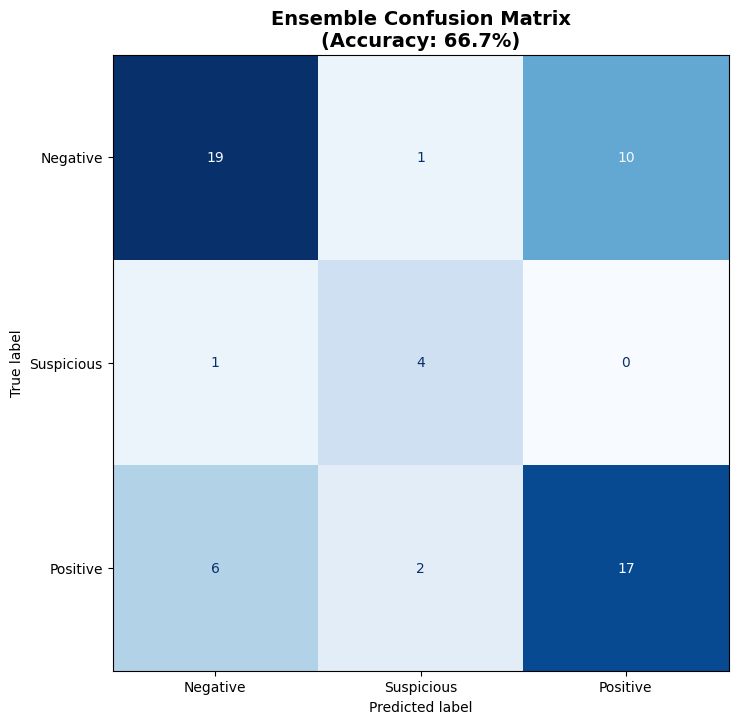

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np # Import numpy as it's used for np.mean and np.std

# --- 6. VISUALIZE CONFUSION MATRIX ---
# Use cm_final and acc_final from the ensemble results
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['Negative', 'Suspicious', 'Positive'])
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title(f"Ensemble Confusion Matrix\n(Accuracy: {acc_final:.1%})", fontsize=14, fontweight='bold')
plt.show()

# --- PLOTTING CODE (Commented out as variables are undefined) ---
# Calculate Averages across 5 folds
# avg_train_loss = np.mean(all_train_loss, axis=0)
# avg_val_loss = np.mean(all_val_loss, axis=0)
# avg_train_acc = np.mean(all_train_acc, axis=0)
# avg_val_acc = np.mean(all_val_acc, axis=0)
# epochs_range = range(1, len(avg_train_loss) + 1)


# plt.figure(figsize=(14, 5))

# # Plot Loss
# plt.subplot(1, 2, 1)
# plt.plot(epochs_range, avg_train_loss, label='Avg Training Loss', color='blue', linestyle='--')
# plt.plot(epochs_range, avg_val_loss, label='Avg Validation Loss', color='red')
# plt.title('Loss Over Time (Avg of 5 Folds)')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.legend()
# plt.grid(True, alpha=0.3)

# # Plot Accuracy
# plt.subplot(1, 2, 2)
# plt.plot(epochs_range, avg_train_acc, label='Avg Training Accuracy', color='blue', linestyle='--')
# plt.plot(epochs_range, avg_val_acc, label='Avg Validation Accuracy', color='green')
# plt.title('Accuracy Over Time (Avg of 5 Folds)')
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.legend()
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()